<a href="https://colab.research.google.com/github/stephanie465337/Data-Science-Portfolio-C21/blob/main/Projects/Project-4/Spotify_Pass_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project 4: Spotify Music Popularity Prediction


##Problem Definition


This project is a **supervised regression** problem focused on predicting the popularity of a new song using features available prior to its release. We will employ tree-based regression models, such as **Decision Tree Regression**, **Random Forest**, and **XGBoost**, to make these predictions. Regularization techniques will be used to reduce overfitting and assist with feature selection. Model performance will be evaluated using *cross-validated* **Root Mean Squared Error** (*RMSE*), with the aim of minimizing prediction error and understanding which features contribute most to a song’s success.

##Data Collection

In [ ]:
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import seaborn           as sns
import xgboost           as xgb
import pickle
import graphviz

from sklearn.model_selection import train_test_split
from sklearn                 import datasets
from sklearn.metrics         import mean_squared_error
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from IPython.display         import display
from sklearn                 import tree

In [ ]:
url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv'
url

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv'

In [ ]:
df = pd.read_csv(url)
df

,Index,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,...,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
0,1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",...,0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589,B
1,2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],...,0.591,0.764,-5.484,0.0483,0.0383,0.103,169.928,141806,0.478,C#/Db
2,3,1,11,2021-06-25--2021-07-02,good 4 u,"40,162,559",Olivia Rodrigo,6266514,4ZtFanR9U6ndgddUvNcjcG,['pop'],...,0.563,0.664,-5.044,0.154,0.335,0.0849,166.928,178147,0.688,A
3,4,3,5,2021-07-02--2021-07-09,Bad Habits,"37,799,456",Ed Sheeran,83293380,6PQ88X9TkUIAUIZJHW2upE,"['pop', 'uk pop']",...,0.808,0.897,-3.712,0.0348,0.0469,0.364,126.026,231041,0.591,B
4,5,5,1,2021-07-23--2021-07-30,INDUSTRY BABY (feat. Jack Harlow),"33,948,454",Lil Nas X,5473565,27NovPIUIRrOZoCHxABJwK,"['lgbtq+ hip hop', 'pop rap']",...,0.736,0.704,-7.409,0.0615,0.0203,0.0501,149.995,212000,0.894,D#/Eb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1551,1552,195,1,2019-12-27--2020-01-03,New Rules,"4,630,675",Dua Lipa,27167675,2ekn2ttSfGqwhhate0LSR0,"['dance pop', 'pop', 'uk pop']",...,0.762,0.7,-6.021,0.0694,0.00261,0.153,116.073,209320,0.608,A
1552,1553,196,1,2019-12-27--2020-01-03,Cheirosa - Ao Vivo,"4,623,030",Jorge & Mateus,15019109,2PWjKmjyTZeDpmOUa3a5da,"['sertanejo', 'sertanejo universitario']",...,0.528,0.87,-3.123,0.0851,0.24,0.333,152.37,181930,0.714,B
1553,1554,197,1,2019-12-27--2020-01-03,Havana (feat. Young Thug),"4,620,876",Camila Cabello,22698747,1rfofaqEpACxVEHIZBJe6W,"['dance pop', 'electropop', 'pop', 'post-teen ...",...,0.765,0.523,-4.333,0.03,0.184,0.132,104.988,217307,0.394,D
1554,1555,198,1,2019-12-27--2020-01-03,Surtada - Remix Brega Funk,"4,607,385","Dadá Boladão, Tati Zaqui, OIK",208630,5F8ffc8KWKNawllr5WsW0r,"['brega funk', 'funk carioca']",...,0.832,0.55,-7.026,0.0587,0.249,0.182,154.064,152784,0.881,F


##Data Cleaning

In [ ]:
df.shape

(1556, 23)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1556 entries, 0 to 1555
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Index                      1556 non-null   int64 
 1   Highest Charting Position  1556 non-null   int64 
 2   Number of Times Charted    1556 non-null   int64 
 3   Week of Highest Charting   1556 non-null   object
 4   Song Name                  1556 non-null   object
 5   Streams                    1556 non-null   object
 6   Artist                     1556 non-null   object
 7   Artist Followers           1556 non-null   object
 8   Song ID                    1556 non-null   object
 9   Genre                      1556 non-null   object
 10  Release Date               1556 non-null   object
 11  Weeks Charted              1556 non-null   object
 12  Popularity                 1556 non-null   object
 13  Danceability               1556 non-null   object
 14  Energy  

###Target

In [ ]:
target_summary = []

for target in df.columns:
  target_summary.append({
    'Target': target,
    'Data Type': df[target].dtype,
    'Null Values': df[target].isnull().sum(),
    'Unique Values': df[target].nunique(),
    'Min': df[target].min(),
    'Max': df[target].max()
  })

pd.DataFrame(target_summary)

,Target,Data Type,Null Values,Unique Values,Min,Max
0,Index,int64,0,1556,1,1556
1,Highest Charting Position,int64,0,200,1,200
2,Number of Times Charted,int64,0,75,1,142
3,Week of Highest Charting,object,0,83,2019-12-27--2020-01-03,2021-07-23--2021-07-30
4,Song Name,object,0,1556,+Linda,‘tis the damn season
5,Streams,object,0,1556,"10,016,907","9,991,177"
6,Artist,object,0,716,*NSYNC,twocolors
7,Artist Followers,object,0,600,,9998991
8,Song ID,object,0,1517,,7zl7kehxesNEo2pYkKXTSe
9,Genre,object,0,395,,[]


####Streams

In [ ]:
target = 'Highest Charting Position'
# target = 'Number of Times Charted'
# target = 'Week of Highest Charting'
# target = 'Streams'
# target = 'Weeks Charted'
# target = 'Popularity'

In [ ]:
# INT     POSSIBLE TARGET
# INT     UNLIKELY TARGET
# TOO COMPLICATED
# df[target] = df[target].str.replace(',', '').astype(int)
# ALL VALUES ARE 1
# ONLY 100 ROWS HAVE VALUES

In [ ]:
df[target].dtype

dtype('O')

In [ ]:
df[target].isnull().sum()

np.int64(0)

In [ ]:
df[target].sort_values() #.tail(12)

,Highest Charting Position
0,1
39,1
46,1
79,1
91,1
...,...
198,199
390,199
1168,199
504,200


In [ ]:
df[target].describe().transpose()

,Highest Charting Position
count,1556.000000
mean,87.744216
std,58.147225
min,1.000000
25%,37.000000
50%,80.000000
75%,137.000000
max,200.000000


###Unique IDs

In [ ]:
identifier_cols = []

for col in df.columns:
    if df[col].nunique() == len(df):
        identifier_cols.append(col)

print(identifier_cols)

['Index', 'Song Name', 'Streams']


In [ ]:
df.drop(columns=[
  'Index',
  'Song Name',
  'Song ID',
  # 'Highest Charting Position',
  'Number of Times Charted',
  'Week of Highest Charting',
  'Streams',
  'Weeks Charted',
  'Popularity'
], inplace=True)
df.head()

,Highest Charting Position,Artist,Artist Followers,Genre,Release Date,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
0,1,Måneskin,3377762,"['indie rock italiano', 'italian pop']",2017-12-08,0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589,B
1,2,The Kid LAROI,2230022,['australian hip hop'],2021-07-09,0.591,0.764,-5.484,0.0483,0.0383,0.103,169.928,141806,0.478,C#/Db
2,1,Olivia Rodrigo,6266514,['pop'],2021-05-21,0.563,0.664,-5.044,0.154,0.335,0.0849,166.928,178147,0.688,A
3,3,Ed Sheeran,83293380,"['pop', 'uk pop']",2021-06-25,0.808,0.897,-3.712,0.0348,0.0469,0.364,126.026,231041,0.591,B
4,5,Lil Nas X,5473565,"['lgbtq+ hip hop', 'pop rap']",2021-07-23,0.736,0.704,-7.409,0.0615,0.0203,0.0501,149.995,212000,0.894,D#/Eb


###Rows

In [ ]:
#Rows with nulls
df.isnull().any(axis = 1).sum()

np.int64(0)

In [ ]:
#Missing rows
df.isnull().sum().sort_values()

,0
Highest Charting Position,0
Artist,0
Artist Followers,0
Genre,0
Release Date,0
Danceability,0
Energy,0
Loudness,0
Speechiness,0
Acousticness,0


In [ ]:
#Duplicate rows
df.duplicated().sum()

np.int64(0)

###Columns

In [ ]:
cols = list(df.drop([target], axis=1).columns.sort_values())
cols

['Acousticness',
 'Artist',
 'Artist Followers',
 'Chord',
 'Danceability',
 'Duration (ms)',
 'Energy',
 'Genre',
 'Liveness',
 'Loudness',
 'Release Date',
 'Speechiness',
 'Tempo',
 'Valence']

####Numerical

#####Discrete

In [ ]:
integer = 'Artist Followers'

In [ ]:
df[integer].sort_values(ascending=True)

,Artist Followers
876,
464,
654,
636,
35,
...,...
863,9949044
856,9949044
228,9987114
1067,9998991


In [ ]:
df[integer] = pd.to_numeric(
  df[integer],
  errors='coerce'
)

df[integer].sort_values(ascending=True)

,Artist Followers
632,4883.0
610,14122.0
149,15889.0
102,16074.0
243,17202.0
...,...
750,NaN
784,NaN
876,NaN
1140,NaN


In [ ]:
df[df[integer].isna()]

,Highest Charting Position,Artist,Artist Followers,Genre,Release Date,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
35,36,The Kid LAROI,NaN,,,,,,,,,,,,
163,5,Ariana Grande,NaN,,,,,,,,,,,,
464,118,Rod Wave,NaN,,,,,,,,,,,,
530,20,Ariana Grande,NaN,,,,,,,,,,,,
636,22,Chris Rea,NaN,,,,,,,,,,,,
654,73,Queen,NaN,,,,,,,,,,,,
750,19,Tainy,NaN,,,,,,,,,,,,
784,76,"Super Yei, Jone Quest",NaN,,,,,,,,,,,,
876,164,Dalex,NaN,,,,,,,,,,,,
1140,131,"AK AUSSERKONTROLLE, Bonez MC",NaN,,,,,,,,,,,,


######Drop 11 Rows with nulls

In [ ]:
df = df.drop(index=[35, 163, 464, 530, 636, 654, 750, 784, 876, 1140, 1538])

In [ ]:
df[integer].dtype

dtype('float64')

In [ ]:
df[integer] = df[integer].fillna(
  df[integer].median()
).astype(int)

df[integer].dtype

dtype('int64')

In [ ]:
df[integer].isna().sum()

np.int64(0)

In [ ]:
integer = 'Duration (ms)'

In [ ]:
df[integer].sort_values(ascending=True)

,Duration (ms)
1499,30133
1030,30583
711,37013
1137,41867
1135,41867
...,...
42,393280
1335,457592
757,484147
265,515865


In [ ]:
df[integer] = pd.to_numeric(
  df[integer],
  errors='coerce'
)

df[integer].sort_values(ascending=True)

,Duration (ms)
1499,30133
1030,30583
711,37013
1137,41867
1135,41867
...,...
42,393280
1335,457592
757,484147
265,515865


In [ ]:
df[df[integer].isna()]

,Highest Charting Position,Artist,Artist Followers,Genre,Release Date,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord


In [ ]:
df[integer].dtype

dtype('int64')

In [ ]:
df[integer] = df[integer].fillna(
  df[integer].median()
).astype(int)

df[integer].dtype

dtype('int64')

In [ ]:
df[integer].isna().sum()

np.int64(0)

In [ ]:
df_int = df.select_dtypes(include=['int64']).drop(columns=[target])
df_int

,Artist Followers,Duration (ms)
0,3377762,211560
1,2230022,141806
2,6266514,178147
3,83293380,231041
4,5473565,212000
...,...,...
1551,27167675,209320
1552,15019109,181930
1553,22698747,217307
1554,208630,152784


#####Continuous

In [ ]:
floats = [
  'Energy',
  'Loudness',
  'Speechiness',
  'Acousticness',
  'Liveness',
  'Tempo',
  'Danceability',
  'Valence'
]

In [ ]:
df[floats] = df[floats].apply(pd.to_numeric, errors='coerce')
df[floats].sort_values(by='Energy', ascending=True, na_position='first').head(12)

,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Danceability,Valence
1505,0.054,-16.735,0.0503,0.947,0.1240,96.838,0.762,0.3390
399,0.103,-14.075,0.0627,0.979,0.0895,124.011,0.484,0.1940
681,0.103,-14.405,0.0404,0.804,0.0760,110.378,0.607,0.3410
670,0.106,-22.507,0.0448,0.994,0.1790,46.718,0.418,0.8000
1180,0.128,-18.717,0.0357,0.894,0.0941,109.986,0.522,0.1240
1546,0.130,-25.166,0.0336,0.900,0.1110,123.342,0.413,0.0676
1400,0.131,-18.435,0.0382,0.953,0.1090,137.421,0.420,0.1200
669,0.139,-12.346,0.0607,0.902,0.1850,84.485,0.700,0.4900
638,0.158,-16.485,0.0381,0.673,0.3380,130.503,0.317,0.2470
656,0.178,-9.402,0.0414,0.957,0.3160,75.248,0.438,0.3440


In [ ]:
df[floats].dtypes

,0
Energy,float64
Loudness,float64
Speechiness,float64
Acousticness,float64
Liveness,float64
Tempo,float64
Danceability,float64
Valence,float64


In [ ]:
df[floats].isnull().sum()

,0
Energy,0
Loudness,0
Speechiness,0
Acousticness,0
Liveness,0
Tempo,0
Danceability,0
Valence,0


In [ ]:
df[floats].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Energy,1545.0,0.633495,0.161577,0.054000,0.5320,0.6420,0.752,0.970
Loudness,1545.0,-6.348474,2.509281,-25.166000,-7.4910,-5.9900,-4.711,1.509
Speechiness,1545.0,0.123656,0.110383,0.023200,0.0456,0.0765,0.165,0.884
Acousticness,1545.0,0.248695,0.250326,0.000025,0.0485,0.1610,0.388,0.994
Liveness,1545.0,0.181202,0.144071,0.019700,0.0966,0.1240,0.217,0.962
Tempo,1545.0,122.811023,29.591088,46.718000,97.9600,122.0120,143.860,205.272
Danceability,1545.0,0.689997,0.142444,0.150000,0.5990,0.7070,0.796,0.980
Valence,1545.0,0.514704,0.227326,0.032000,0.3430,0.5120,0.691,0.979


####Categorical

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1545 entries, 0 to 1555
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Highest Charting Position  1545 non-null   int64  
 1   Artist                     1545 non-null   object 
 2   Artist Followers           1545 non-null   int64  
 3   Genre                      1545 non-null   object 
 4   Release Date               1545 non-null   object 
 5   Danceability               1545 non-null   float64
 6   Energy                     1545 non-null   float64
 7   Loudness                   1545 non-null   float64
 8   Speechiness                1545 non-null   float64
 9   Acousticness               1545 non-null   float64
 10  Liveness                   1545 non-null   float64
 11  Tempo                      1545 non-null   float64
 12  Duration (ms)              1545 non-null   int64  
 13  Valence                    1545 non-null   float64
 1

Objects left
- Artist
- Genre
- Release Date
- Chord

In [ ]:
#Artist Followers captures that Artist's recognition
df.drop(columns=['Artist'], inplace=True)

In [ ]:
#Genre
df = pd.get_dummies(
    df,
    columns=['Genre'],
    drop_first=True
)

In [ ]:
#Release Date
df['Release Date'] = pd.to_datetime(df['Release Date'], format='mixed')

In [ ]:
df['Release Year'] = df['Release Date'].dt.year

In [ ]:
df['Release Month'] = df['Release Date'].dt.month

In [ ]:
df.drop(columns=['Release Date'], inplace=True)

In [ ]:
#Chord
df['Chord'].value_counts()

,count
Chord,
C#/Db,214
C,155
B,141
G,136
F,131
G#/Ab,130
D,125
A#/Bb,122
F#/Gb,121


In [ ]:
df = pd.get_dummies(
    df,
    columns=['Chord'],
    drop_first=True
)

In [ ]:
df

,Highest Charting Position,Artist Followers,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),...,Chord_B,Chord_C,Chord_C#/Db,Chord_D,Chord_D#/Eb,Chord_E,Chord_F,Chord_F#/Gb,Chord_G,Chord_G#/Ab
0,1,3377762,0.714,0.800,-4.808,0.0504,0.12700,0.3590,134.002,211560,...,True,False,False,False,False,False,False,False,False,False
1,2,2230022,0.591,0.764,-5.484,0.0483,0.03830,0.1030,169.928,141806,...,False,False,True,False,False,False,False,False,False,False
2,1,6266514,0.563,0.664,-5.044,0.1540,0.33500,0.0849,166.928,178147,...,False,False,False,False,False,False,False,False,False,False
3,3,83293380,0.808,0.897,-3.712,0.0348,0.04690,0.3640,126.026,231041,...,True,False,False,False,False,False,False,False,False,False
4,5,5473565,0.736,0.704,-7.409,0.0615,0.02030,0.0501,149.995,212000,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1551,195,27167675,0.762,0.700,-6.021,0.0694,0.00261,0.1530,116.073,209320,...,False,False,False,False,False,False,False,False,False,False
1552,196,15019109,0.528,0.870,-3.123,0.0851,0.24000,0.3330,152.370,181930,...,True,False,False,False,False,False,False,False,False,False
1553,197,22698747,0.765,0.523,-4.333,0.0300,0.18400,0.1320,104.988,217307,...,False,False,False,True,False,False,False,False,False,False
1554,198,208630,0.832,0.550,-7.026,0.0587,0.24900,0.1820,154.064,152784,...,False,False,False,False,False,False,True,False,False,False


###Copy

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1545 entries, 0 to 1555
Columns: 417 entries, Highest Charting Position to Chord_G#/Ab
dtypes: bool(404), float64(8), int32(2), int64(3)
memory usage: 766.5 KB


In [ ]:
df_clean = df.copy()

##Exploratory Data Analysis (EDA)

###Histogram

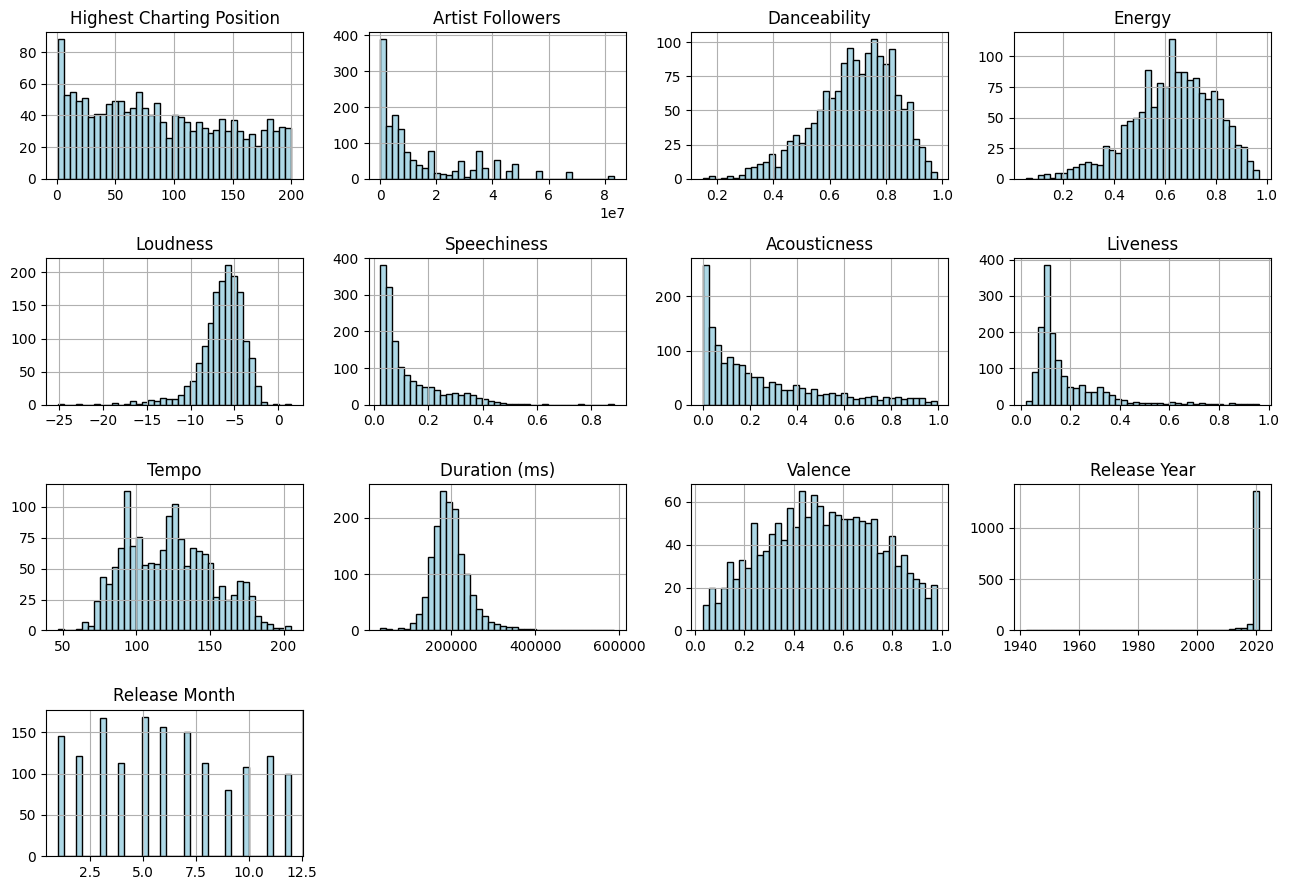

In [ ]:
n = int(1556**(1/2)) # bins

df_clean.hist(figsize=(13,9), bins=n, color='lightblue', edgecolor='black')

plt.tight_layout()
plt.show()

##Processing

In [ ]:
X = df_clean.drop(target, axis = 1)
y = df_clean[target]

###Decision Tree Regression

In [ ]:
numLoops = 500 #Arbitrarily choose how many times to run?

rms_error = np.zeros(numLoops) #Stores the RMSE score from each loop.

for idx in range(0,numLoops): #Repeats 500 times.
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
  model = DecisionTreeRegressor(max_depth=3) # Arbitrarily choosing max_depth of 3
  model.fit(X_train,y_train) #Uses the products from X_train and the correct answers in y_train to learn patterns.
  y_pred = model.predict(X_test) #Makes prediction
  rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"CV RMSE: {rms_error.mean().round(2)*1000}") #Average of RMSE values from loop.

CV RMSE: 55680.0


####How do we choose the tree depth?

In [ ]:
max_depths = [1,2,3,4,5,6,7,8,9,10] #Runs different max depths
rms_depth = np.zeros(len(max_depths)) #Ang RMSE for depth
std_depth = np.zeros(len(max_depths)) #Consistency

numLoops = 500

for n, depth in enumerate(max_depths):
  rms_error = np.zeros(numLoops)

  for idx in range(0,numLoops):
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
    model = DecisionTreeRegressor(max_depth=depth)
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

  rms_depth[n] = rms_error.mean()
  std_depth[n] = rms_error.std(ddof = 1)

In [ ]:
results = pd.DataFrame({
  'Max Depth': max_depths,
  'Mean RSME': rms_depth,
  'Std RMSE': std_depth
})

results

,Max Depth,Mean RSME,Std RMSE
0,1,56.928734,1.494705
1,2,55.980584,1.506846
2,3,55.718092,1.645749
3,4,56.024865,1.635046
4,5,56.683764,1.910122
5,6,57.612170,1.947645
6,7,58.753794,2.235530
7,8,60.363526,2.398677
8,9,62.067320,2.659773
9,10,63.482004,2.707700


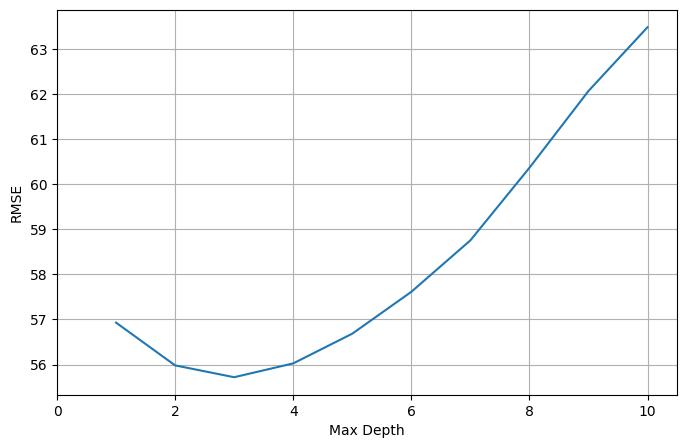

In [ ]:
#Plot result
plt.figure(figsize = (8,5))
plt.plot(max_depths, rms_depth)
plt.xlabel('Max Depth')
plt.ylabel('RMSE')
plt.xlim(0, 10.5)
plt.grid()

In [ ]:
#Re run with max depth = 4
numLoops = 500

rms_error = np.zeros(numLoops)

for idx in range(0, numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
  model = DecisionTreeRegressor(max_depth=4)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"CV RMSE: {rms_error.mean().round(2)*1000}")

CV RMSE: 56040.0


####Visualize the Decision Tree

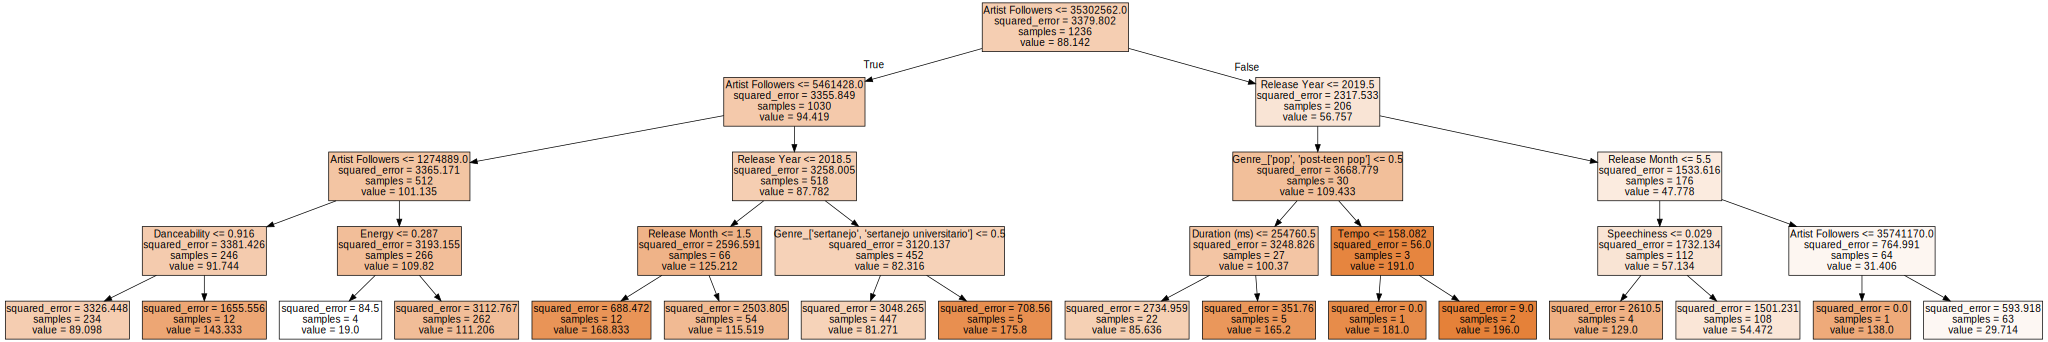

In [ ]:
#Readable view
display(
  graphviz.Source(
    tree.export_graphviz(
      model,
      feature_names = X.columns,
      filled = True,
    )
  )
)

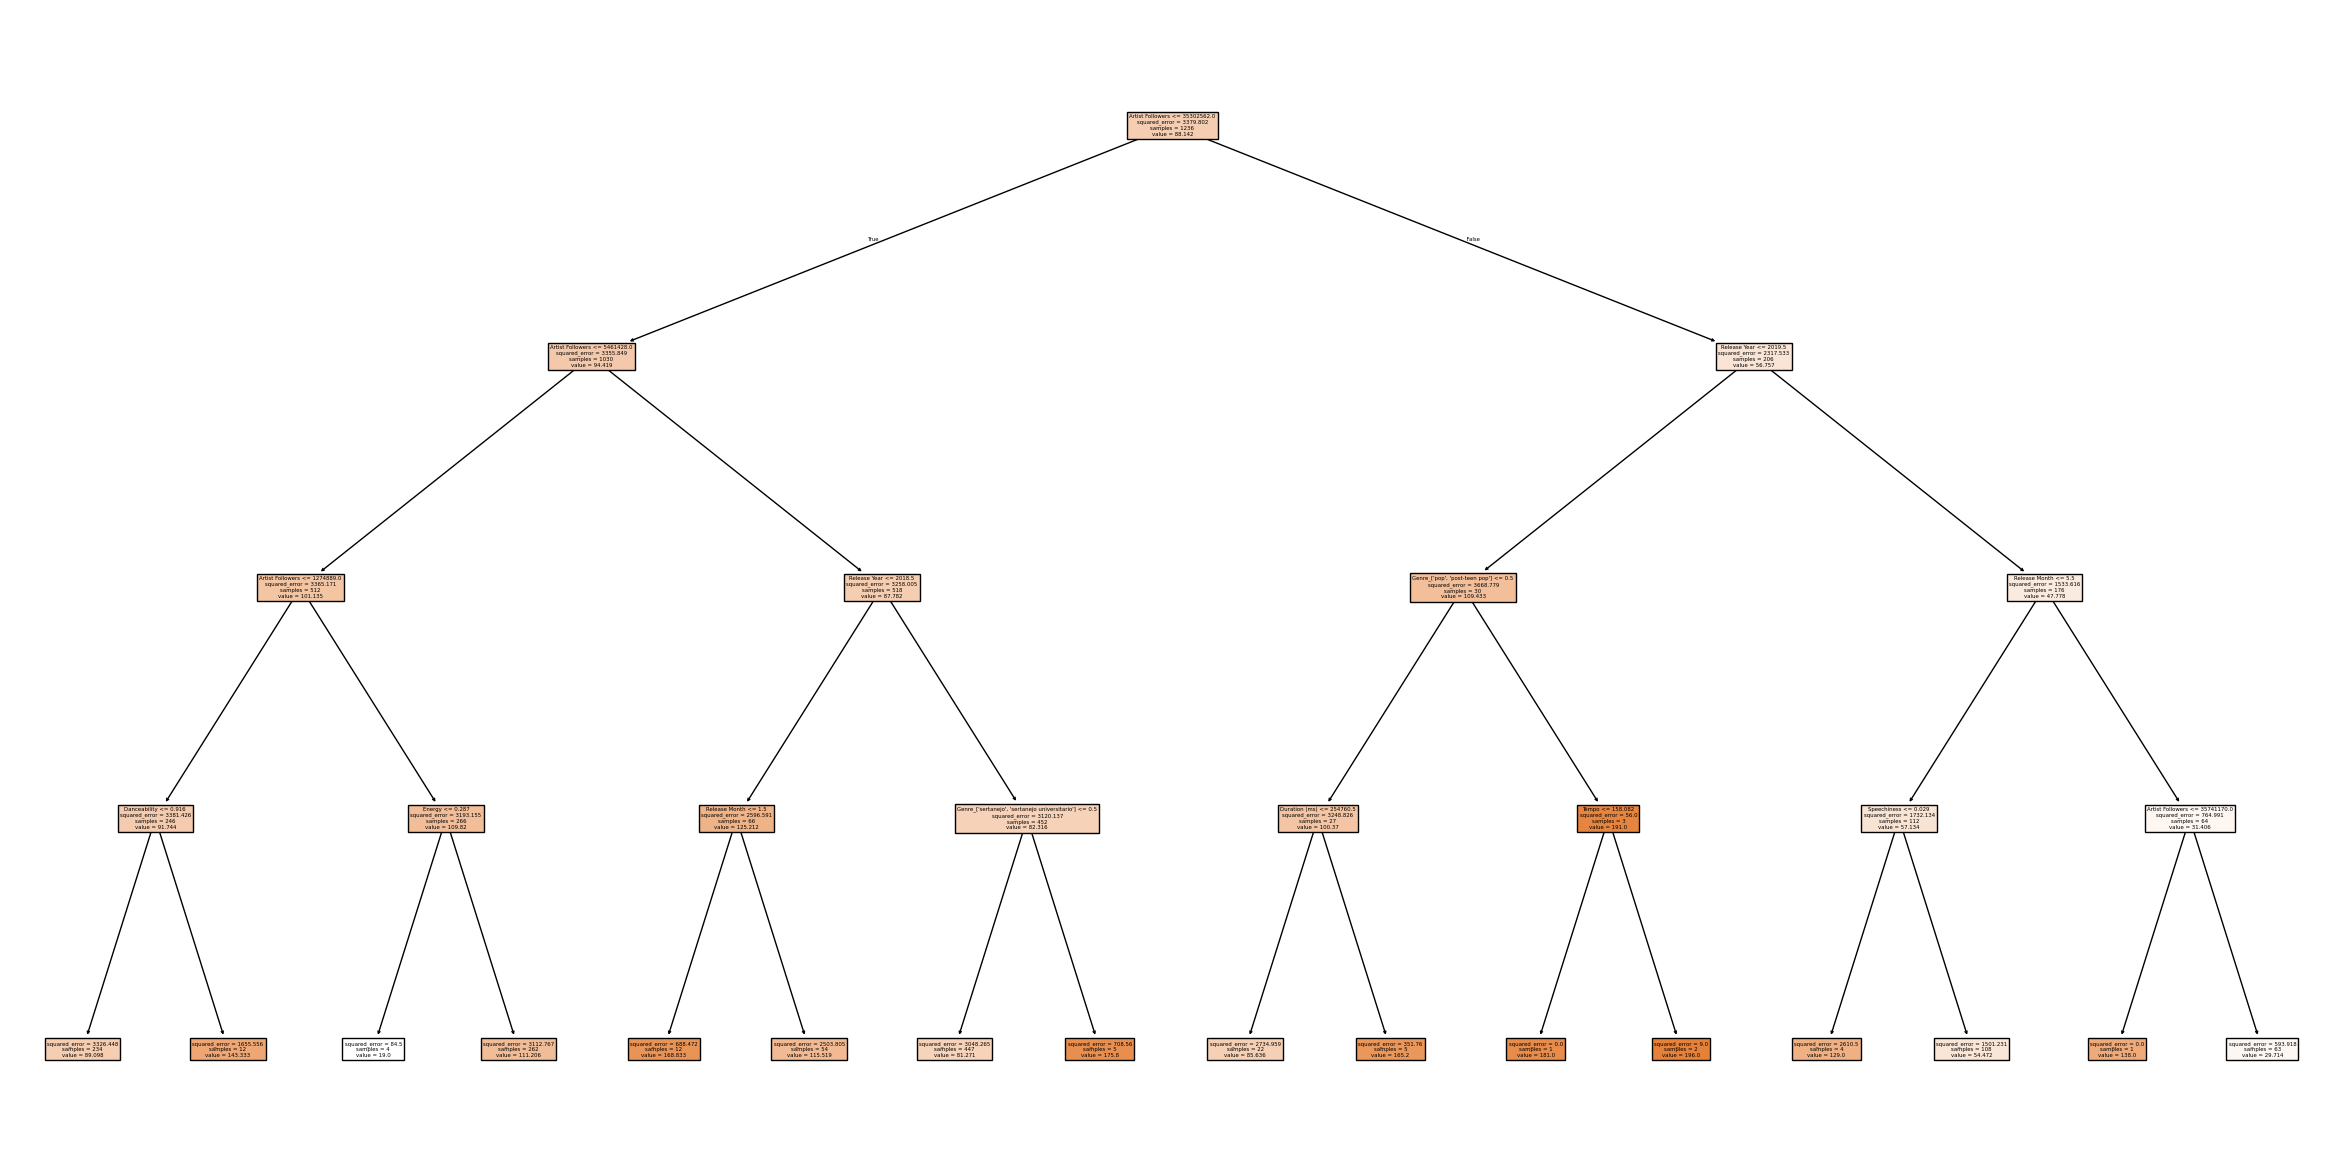

In [ ]:
#Full view
plt.figure(figsize=(30,15))
tree_plot = tree.plot_tree(
  model,
  feature_names = X.columns,
  filled=True,
)

###Random Tree

In [ ]:
#This line intentionally left blank
numLoops = 500

mean_error = np.zeros(numLoops)

np.random.seed(42)
for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
  model = DecisionTreeRegressor(max_depth=4, random_state=0)
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)
  mean_error[idx] = mean_squared_error(y_test, y_pred)

print(f'RMSE: {np.sqrt(mean_error).mean()*1000}')
print(f'RMSE_std: {np.sqrt(mean_error).std()*1000}')

In [ ]:
#Two parameters - n_estimators (number of trees), max_depth (number of splits)
numLoops = 500

mean_error = np.zeros(numLoops)

# np.random.seed(42)
for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)
  model = RandomForestRegressor(n_estimators = 10) # n_estimators is number of trees in forest. Note: you can also choose max_depth for RFs
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  mean_error[idx] = mean_squared_error(y_test, y_pred)

print(f'RMSE: {np.sqrt(mean_error).mean()*1000}')
print(f'RMSE_std: {np.sqrt(mean_error).std()*1000}')
np.sqrt(mean_error)[:50]

####How do you choose number of trees?

In [ ]:
num_trees = range(10,60,10)
cv_loops = 100
rmse_results = np.zeros(len(num_trees))
std_results = np.zeros(len(num_trees))

for n, trees in enumerate(num_trees):
  rmse_cv = np.zeros(cv_loops)
  np.random.seed(42)
  for i in range(cv_loops):
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20)
    rfModel = RandomForestRegressor(n_estimators=trees)
    rfModel.fit(X_train, y_train)
    y_pred_rf = rfModel.predict(X_test)
    rmse_cv[i] = np.sqrt(mean_squared_error(y_test, y_pred_rf))

  print(trees,' trees finished.')
  rmse_results[n] = rmse_cv.mean()
  std_results[n] = rmse_cv.std()

In [ ]:
pickle.dump(rfModel, open('rfModel.p','wb'))

In [ ]:
plt.plot(num_trees, rmse_results)
plt.xlabel('Tree No.')
plt.ylabel('RMSE')
plt.grid()

In [ ]:
pd.DataFrame(zip(num_trees, rmse_results, std_results), columns='depth RMSE STDev'.split())

In [ ]:
# plt.errorbar(num_trees, rmse_results, yerr=(std_results*2,std_results*2))
plt.errorbar(num_trees, rmse_results, yerr=std_results)
plt.xlabel('Tree No.')
plt.ylabel('RMSE')
plt.ylim(0,5)
plt.xlim(0,55)
plt.grid()

In [ ]:
print(f'RMSE with 30 trees: {rmse_results[2]*1000}')

In [ ]:
import graphviz
from IPython.display import display
from sklearn import tree

In [ ]:
len(rfModel.estimators_)

In [ ]:
#Display one tree from the random forest
display(
  graphviz.Source(
    tree.export_graphviz(
      rfModel.estimators_[0],
      feature_names = X.columns,
    )
  )
)

####Find Important Predictors

In [ ]:
importances = rfModel.feature_importances_
forest_importances = pd.Series(importances, index = X.columns)

plt.figure()
# forest_importances.plot.bar()
forest_importances.sort_values(ascending=True).plot.bar()
plt.title("Feature importances")
plt.ylabel('Feature Importance Score');

In [ ]:
(forest_importances.sort_values(ascending=False) * 100).cumsum()

###XGBooster

In [ ]:
numLoops = 100
mse_xgb  = np.zeros(numLoops)

for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.15)
  xgbr = xgb.XGBRegressor(objective ='reg:squarederror', verbosity=0, seed = 10)
  xgbr.fit(X_train,y_train)
  y_pred_xgb = xgbr.predict(X_test)
  mse_xgb[idx] = mean_squared_error(y_test,y_pred_xgb)

print(f'RMSE: {np.sqrt(mse_xgb).mean()*1000}')

In [ ]:
y_pred_xgb[0]

In [ ]:
y_test.to_numpy()[0]

In [ ]:
my_house = X_test[:3]
my_house

In [ ]:
xgbr.predict(my_house)

In [ ]:
y_test[:3]

####XGBoost with Parameters

In [ ]:
#Specify the parameters you want to try and their ranges.
param_test = {
 'max_depth'     : [3, 4, 5, 6, 7],
 'learning_rate' : [0.1, 0.2, 0.3, 0.4],
 'n_estimators'  : [20, 40, 60, 80, 100, 120, 140]
}

#Perform the grid search
#This is the Cross Validation (140)
gsearch = GridSearchCV(
    estimator = xgb.XGBRegressor(objective = 'reg:squarederror', seed = 10),
    param_grid = param_test,
    scoring = 'neg_mean_squared_error',
    cv = 5,
)

#Fit to training data
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.05, random_state = 42)
model = gsearch.fit(X_train,y_train)

#See grid search results
print(model.best_params_)

Now we will fit our XGBoost model with the best parameters

In [ ]:
params = model.best_params_

numLoops = 100
mse_xgb  = np.zeros(numLoops)

for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.15)
  xgbr = xgb.XGBRegressor(
      objective ='reg:squarederror',
      verbosity=0,
      #Unpack a dictionary (* to unpack a list)
      **params,
      # learning_rate = 0.2,
      # max_depth = 3,
      # n_estimators = 100,
      seed = 10 #To be reproducable
  )
  xgbr.fit(X_train,y_train)
  y_pred_xgb = xgbr.predict(X_test)
  mse_xgb[idx] = mean_squared_error(y_test,y_pred_xgb)

print(f'RMSE: {np.sqrt(mse_xgb).mean()*1000}')

In [ ]:
feat_imp = pd.Series(xgbr.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize = (10,6))
sns.barplot(x = feat_imp.index, y = feat_imp.values)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Feature')
plt.ylabel('Feature Importance Score');

In [ ]:
(feat_imp.sort_values(ascending=False)*100).cumsum()

##Conclusion and Future Work

Changes
- Cleaned up notebook
- Attempted One-Hot Encoding
- Refined Problem Definition
- Organized targets to try them all
Conclusions
- Looked deeper into all targets
- RMSE went down
- Experimented with new target

Future Work
- Clean up
- Take a look at RMSPE?